In [1]:
from myutils import *
from scipy.optimize import minimize
from src import LoadEstimates, MetaData, Estimates, FrequencyEstimation, qCMOS, DI, SPADE, DMD

In [2]:
raw = np.load(r'c:\Users\Administrator\Desktop\10.19\spade_0.1.npy')
meta = MetaData('SPADE', 0.1, 5 * DMD.PIXEL_SIZE / 2, np.load(r'c:\Users\Administrator\Desktop\10.19\timestamp_0.1.npy'))

c = FrequencyEstimation(raw, meta)

In [3]:
spade_td = c.time_domain

In [4]:
di_td = LoadEstimates(r'c:\Users\Administrator\Desktop\11.2\estimates\di_0.1.npz').time_domain

In [23]:
open_myutils()

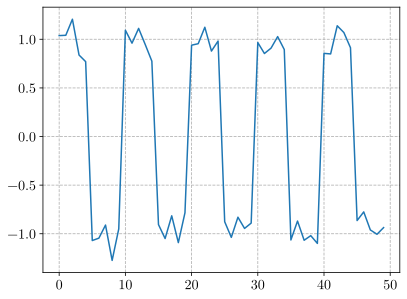

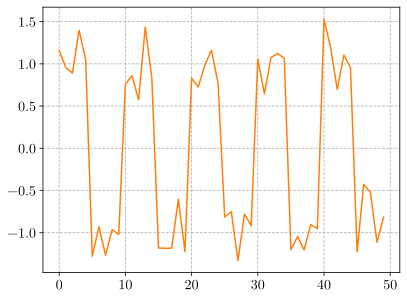

In [41]:
inline_format('svg')
style_use('paper2')
x = np.arange(50)
plt.plot(x, (di_td[0] - di_td[0].mean()) / di_td.std())
plt.grid(True, linestyle='--')
# plt.title("DI's time-domain")
plt.show()
plt.plot(x, (spade_td[0] - spade_td[0].mean()) / spade_td.std(), 'C1')
plt.grid(True, linestyle='--')
# plt.title("SPADE's time-domain")
plt.show()

In [9]:
open_myutils()

In [28]:
k = np.sqrt((c.cropped_data - 200)[..., 0] / (c.cropped_data - 200)[..., 1])
spade_td_s = 2 * 103 * (1-k)/(1+k)

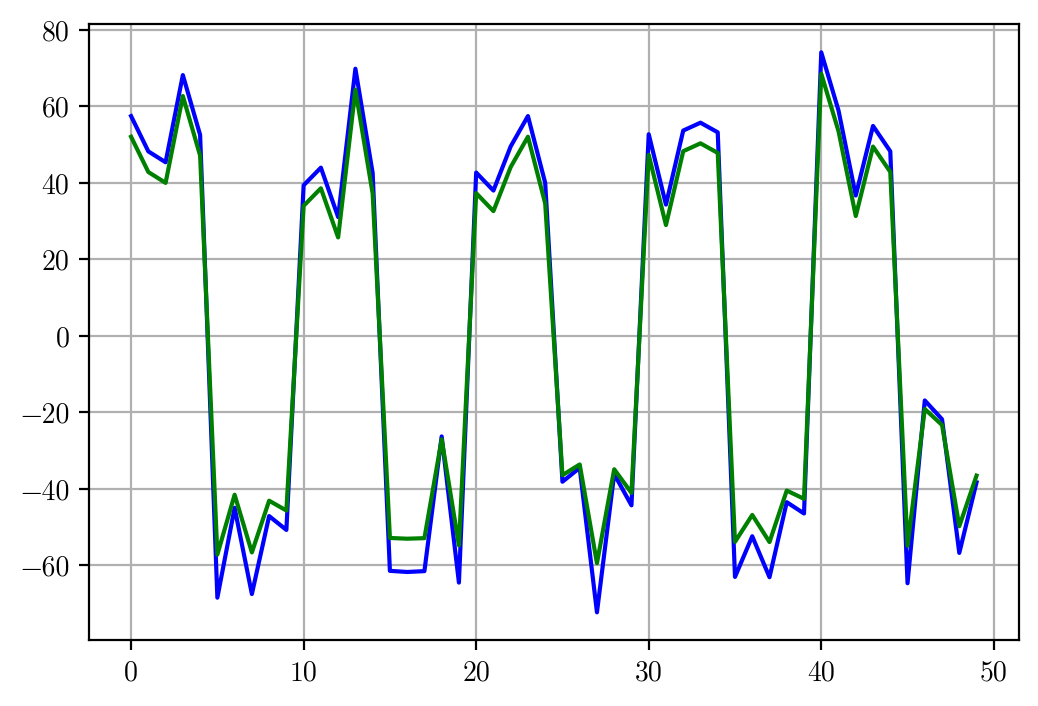

In [29]:
plot((spade_td_s[0] - spade_td_s[0].mean()))
plot((spade_td[0] - spade_td[0].mean()) * 4.6)

In [3]:
SPADE.__name__

'SPADE'

In [1]:
from src import *
from myutils import *

In [2]:
c = Estimates.load(r'f:\__estimates__\20241104\spade_0.1.npz')

In [3]:
c2 = FrequencyEstimation.FromEstimates(c)
c = Estimates.load(r'f:\__estimates__\20241104\spade_0.1.npz')

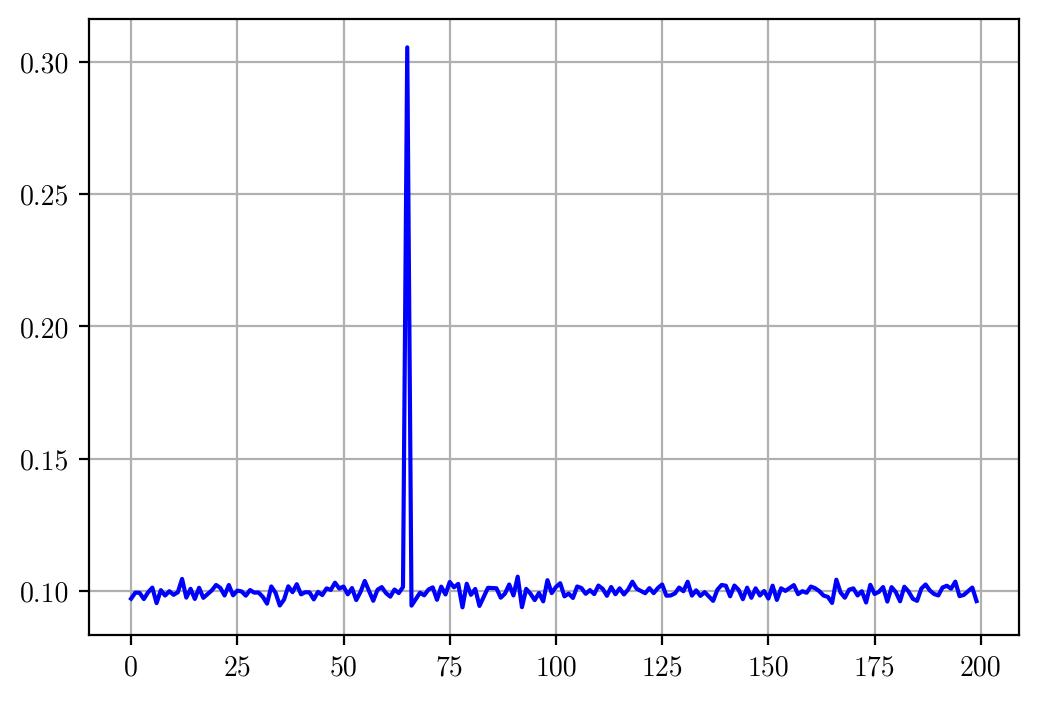

In [4]:
plot(c.frequency_estmates)

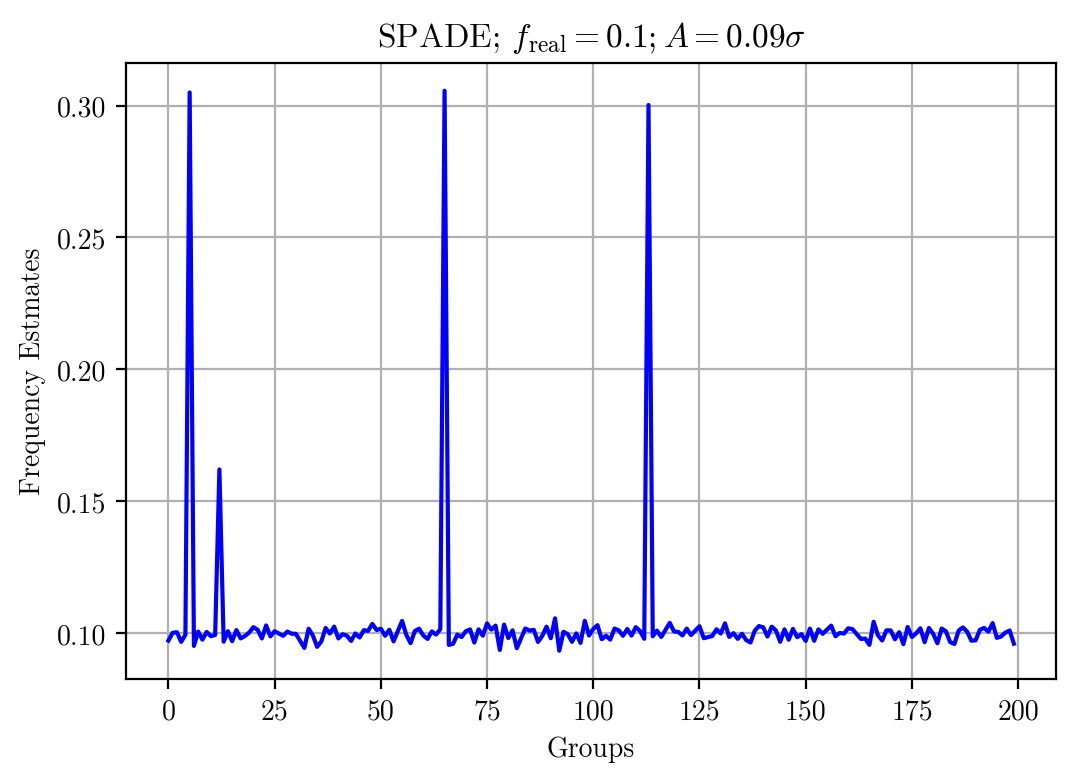

In [35]:
plot(c2.frequency_estmates)
plot(ylabel='Frequency Estmates', xlabel='Groups', title=r'SPADE; $f_{\rm real} = 0.1; A = 0.09\sigma$')

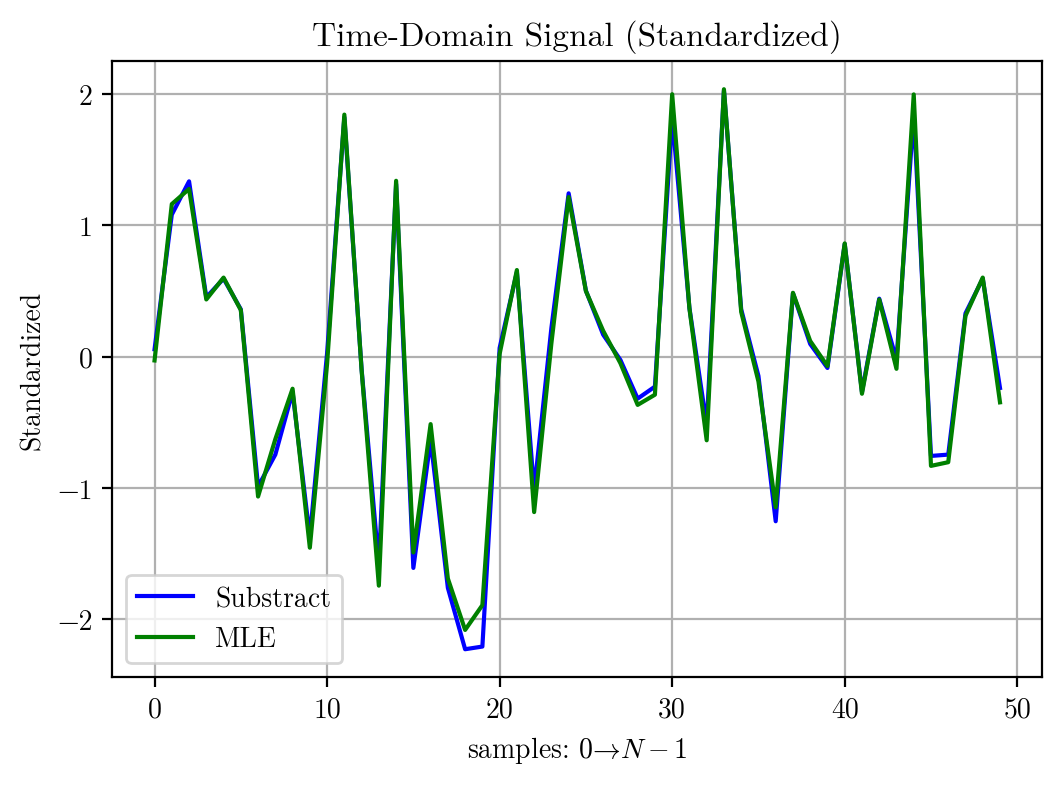

In [32]:
plot((c.time_domain[5] - c.time_domain[5].mean()) / c.time_domain[5].std(), label='Substract')
plot((c2.time_domain[5] - c2.time_domain[5].mean()) / c2.time_domain[5].std(), label='MLE')
plot(title='Time-Domain Signal (Standardized)')
plot(ylabel='Standardized', xlabel=r'samples: $0\to N-1$')

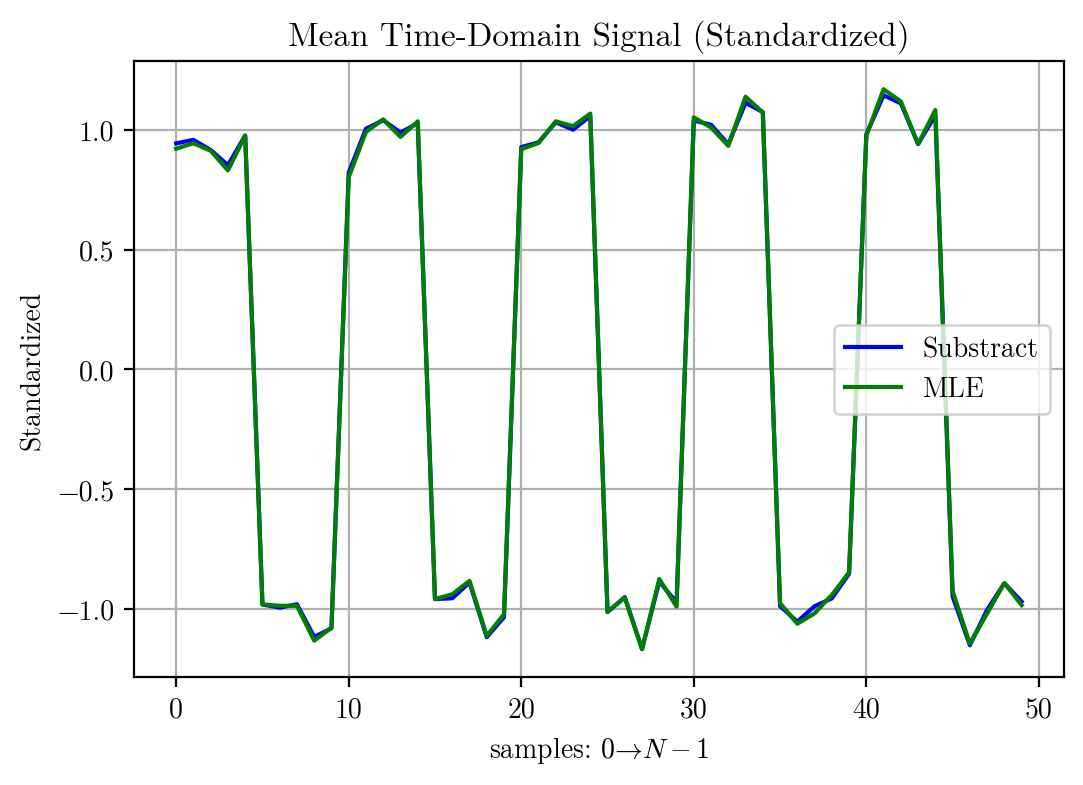

In [41]:
plot((c.time_domain.mean(0) - c.time_domain.mean(0).mean()) / c.time_domain.mean(0).std(), label='Substract')
plot((c2.time_domain.mean(0) - c2.time_domain.mean(0).mean()) / c2.time_domain.mean(0).std(), label='MLE')
plot(title='Mean Time-Domain Signal (Standardized)')
plot(ylabel='Standardized', xlabel=r'samples: $0\to N-1$')

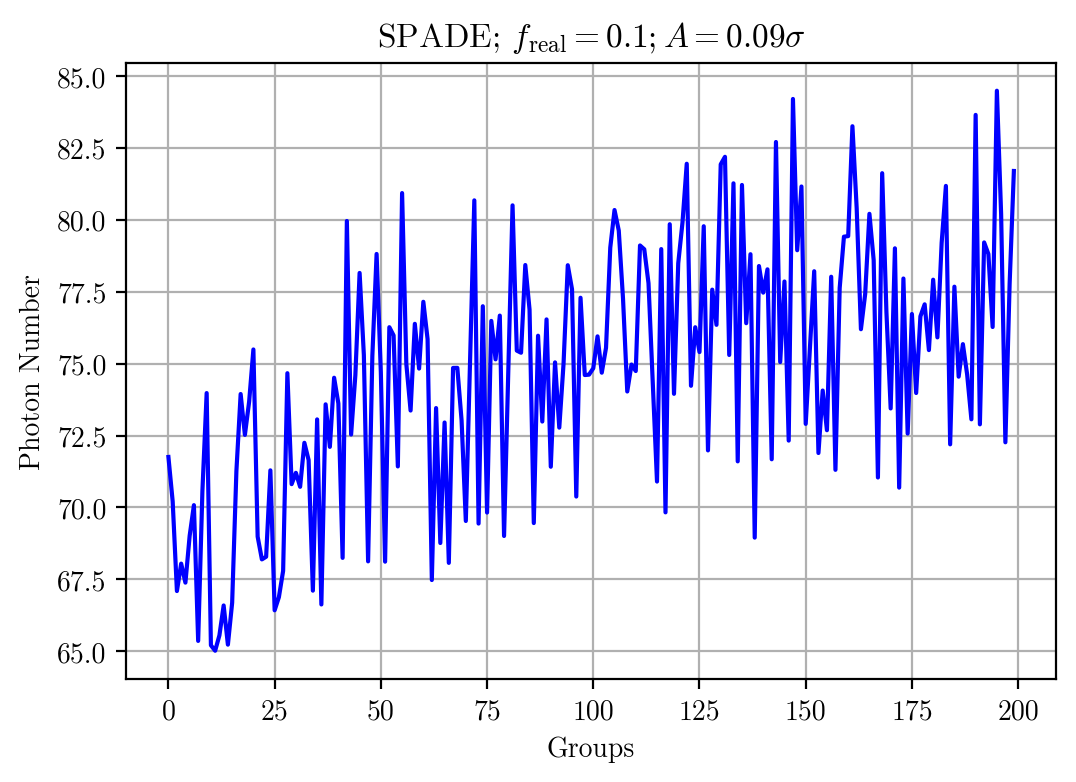

In [42]:
plot(c2.photons.mean(-1))
plot(ylabel='Photon Number', xlabel='Groups', title=r'SPADE; $f_{\rm real} = 0.1; A = 0.09\sigma$')

In [1]:
from src import *
from myutils import *

In [2]:
@email_notify('hcnzj@qq.com')
def f():
    for _f in tqdm(np.linspace(0.1, 0.4, 61)):
        f = np.round(_f, 5)

        raw = np.load(rf'__raw__/20241106/di_{f}_raw.npy')
        timestamp = np.load(rf'__raw__/20241106/di_{f}_timestamp.npy')

        meta = MetaData('DI', f, 5*DMD.PIXEL_SIZE/2, timestamp)

        c = FrequencyEstimation.FromRaw(raw, meta)
        c.savez(rf'__estimates__/20241106/di_{f}.npz')

f()

  0%|          | 0/61 [00:00<?, ?it/s]

 18%|█▊        | 11/61 [02:40<12:13, 14.68s/it]